# # ML - 지도학습 - Classification 실습

[사용 제한 안내]
> 본 실습 코드는 교육 및 학습 목적으로만 제공됩니다.

[사전 준비 사항]
- 없음

[분석 요건]
- 분석 주제 : 다양한 머신러닝 기법을 활용한 타이타닉 생존 예측 모델 개발 *타이타닉: 당시 세계 최대 여객선으로 1912년 빙산과 충돌하여 침몰한 역사적인 선박
- 분석 단위 : 승객
- 종속 변수 : 생존 여부 (Survived)
- 설명 변수 : 승객정보 (성별, 나이, 운임, 부모/자녀 수, 객실번호 등)

[주요 실습 내용]
- 로지스틱 회귀
- 의사결정나무
- Random Forest
- XGBoost
- LightGBM


# 데이타 준비
- 타이타닉(Titanic) 데이타 : titanic.csv
- 데이타 설명 : 타이타닉 배 침몰사고 당시의 실제 데이타를 기반으로 승객의 정보를 이용하여 생존 여부(Survived)를 예측하기 위함
- 변수 설명

| 변수          | 설명                 | 데이터 유형      |
| ----------- | ------------------ | ----------- |
| PassengerId | 승객 고유번호            | ID          |
| Survived    | 생존 여부 (0=사망, 1=생존) | Target      |
| Pclass      | 객실 등급 (1,2,3등석)    | 연속형    |
| Name        | 승객 이름              | 문자열         |
| Sex         | 성별                 | 범주형         |
| Age         | 나이                 | 연속형         |
| SibSp       | 함께 탑승한 형제·배우자 수    | 연속형     |
| Parch       | 함께 탑승한 부모·자녀 수     | 연속형     |
| Ticket      | 티켓 번호              | 문자열         |
| Fare        | 운임                 | 연속형         |
| Cabin       | 객실 번호              | 범주형 |
| Embarked    | 승선 항구(C, Q, S)     | 범주형         |



데이타 불러오기

In [2]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
import warnings

warnings.filterwarnings("ignore")  # 경고 메시지 무시

# 데이터 불러오기
url = "https://raw.githubusercontent.com/datasciencedojo/datasets/master/titanic.csv"
df = pd.read_csv(url)
df

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S
...,...,...,...,...,...,...,...,...,...,...,...,...
886,887,0,2,"Montvila, Rev. Juozas",male,27.0,0,0,211536,13.0000,NaN,S
887,888,1,1,"Graham, Miss. Margaret Edith",female,19.0,0,0,112053,30.0000,B42,S
888,889,0,3,"Johnston, Miss. Catherine Helen ""Carrie""",female,NaN,1,2,W./C. 6607,23.4500,NaN,S
889,890,1,1,"Behr, Mr. Karl Howell",male,26.0,0,0,111369,30.0000,C148,C


분석 변수 선택

In [3]:
# 사용할 변수 선택
df = df[['Survived', 'Pclass', 'Sex', 'Age', 'SibSp', 'Parch', 'Fare']]

컬럼정보 확인

In [4]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 7 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   Survived  891 non-null    int64  
 1   Pclass    891 non-null    int64  
 2   Sex       891 non-null    str    
 3   Age       714 non-null    float64
 4   SibSp     891 non-null    int64  
 5   Parch     891 non-null    int64  
 6   Fare      891 non-null    float64
dtypes: float64(2), int64(4), str(1)
memory usage: 52.9 KB


[참고] info()에서 확인할 것:
  - 총 행/열 수
  - 각 컬럼의 데이터 타입
    - int : 연속형 (정수형)
    - float : 연속형 (실수형)
    - object : 보통 문자열 (범주형)
    - category : 범주형,  *범주 갯수가 적을 경우 메모리 효율화를 위해 object 타입 대신 사용, 그러나 object 을 사용해도 무방
    - datetime : 날짜형

# EDA

연속형 변수 기본 분포값 확인
 - 비즈니스관점에서 데이터 이상 여부 확인, 특히 음수(-), '0' 데이터 주의
 - Missing 건수 확인
 - 데이터 최소, 최대, 중심값 확인
 - 데이터 밀집도 확인

In [5]:
import numpy as np

# 연속형 변수 기본 분포 확인
df.select_dtypes(include=[np.number]).describe()

,Survived,Pclass,Age,SibSp,Parch,Fare
count,891.000000,891.000000,714.000000,891.000000,891.000000,891.000000
mean,0.383838,2.308642,29.699118,0.523008,0.381594,32.204208
std,0.486592,0.836071,14.526497,1.102743,0.806057,49.693429
min,0.000000,1.000000,0.420000,0.000000,0.000000,0.000000
25%,0.000000,2.000000,20.125000,0.000000,0.000000,7.910400
50%,0.000000,3.000000,28.000000,0.000000,0.000000,14.454200
75%,1.000000,3.000000,38.000000,1.000000,0.000000,31.000000
max,1.000000,3.000000,80.000000,8.000000,6.000000,512.329200


범주형 변수 기본 분포값 확인
 - 비즈니스관점에서 데이터 이상 여부 확인
 - Missing 건수 확인
 - 데이터 밀집도 확인
 - 범주 갯수 확인

In [6]:
# 범주형 변수 자동 추출
cat_cols = df.select_dtypes(include=['object', 'category']).columns

# 범주 건수 & 비율 계산
for col in cat_cols:
    print(f"\n[{col}]")
    dist = df[col].value_counts(dropna=False)
    ratio = df[col].value_counts(normalize=True, dropna=False) * 100
    result = pd.DataFrame({
        "count": dist,
        "ratio_%": ratio.round(2)
    })
    print(result)


[Sex]
        count  ratio_%
Sex                   
male      577    64.76
female    314    35.24


# 데이타 분할

X, y 분리

In [7]:
# X, y 분리
X = df.drop('Survived', axis=1)
y = df['Survived']

Data Partition

- 목적 : 모델이 학습에 사용하지 않은 새로운 데이터에서도 잘 동작하는지 검증하기 위함
 - Train  : Test 비율 (7 : 3)
 - Train Set : 모델 학습용, Test Set : 모델 평가용
- 데이타 변환시 변환 통계량은 Train 데이터에서 계산하고, Test 데이터에는 그 기준을 적용해야 함 (Data Leakage 문제)

In [8]:
from sklearn.model_selection import train_test_split

# Train/Test 분리
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.3, random_state=42
)

# Feature Transformation

Missing 처리
  - 연속형: 중앙값 대체

In [9]:
import numpy as np
import pandas as pd

# 연속형 변수 선택
num_cols = X_train.select_dtypes(include=[np.number]).columns

# Train 기준 중앙값 계산
median_values = X_train[num_cols].median()

# Train, Test 모두 Train 기준 중앙값으로 대체
X_train[num_cols] = X_train[num_cols].fillna(median_values)
X_test[num_cols] = X_test[num_cols].fillna(median_values)

- 범주형: New Class 대체

In [10]:
# 범주형 변수 선택
cat_cols = X_train.select_dtypes(include=["object", "category"]).columns

# 신규 범주(Unknown)로 대체
for col in cat_cols:

    # Train
    if X_train[col].dtype.name == "category":
        X_train[col] = X_train[col].cat.add_categories("Unknown")
    X_train[col] = X_train[col].fillna("Unknown")

    # Test
    if X_test[col].dtype.name == "category":
        X_test[col] = X_test[col].cat.add_categories("Unknown")
    X_test[col] = X_test[col].fillna("Unknown")

범주형 변수 -> 수치형 변수로 변환
- 수동 매핑 *일반적으로는 One-Hot Encoding 처리
   

In [11]:
# 성별을 숫자로 (male=0, female=1) 변환
X_train['Sex'] = X_train['Sex'].map({'male': 0, 'female': 1})
X_test['Sex'] = X_test['Sex'].map({'male': 0, 'female': 1})

# 로지스틱 회귀
   - 로지스틱 회귀란? 선형회귀 결과를 확률(0~1)로 변환하는 알고리즘
   - API 문서 : https://scikit-learn.org/stable/modules/generated/sklearn.linear_model.LogisticRegression.html

   학습 및 예측

In [12]:
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score

# 모델 정의
model = LogisticRegression(max_iter=1000)

# 모델 학습
model.fit(X_train, y_train)

# 예측값 생성: 1) 예측 분류
train_pred = model.predict(X_train)
test_pred = model.predict(X_test)
print("예측 분류:\n", test_pred[:5])

# 예측값 생성: 2) 예측 확률
train_pred_score = model.predict_proba(X_train)
test_pred_score = model.predict_proba(X_test)
print("\n예측 확률:\n", test_pred_score[:5])   #1번째 컬럼; class 0(사망)일 확률 , 2번째 컬럼; class 1(생존)일 확률

# 모델 평가
print(f"\nTrain 정확도: {accuracy_score(y_train, train_pred):.3f}")
print(f"Test  정확도: {accuracy_score(y_test, test_pred):.3f}")

예측 분류:
 [0 0 0 1 1]

예측 확률:
 [[0.91378999 0.08621001]
 [0.76530862 0.23469138]
 [0.84744558 0.15255442]
 [0.10449228 0.89550772]
 [0.32789029 0.67210971]]

Train 정확도: 0.796
Test  정확도: 0.813


### [Self-Practice]

- 실습 주제 : 본인 정보를 넣어 생존 확률 예측
- 실습 조건
   - Feature 중 성별, 연령, 형제자매수, 부모자녀수 는 현재 본인의 정보를 입력
   - 아래 예시 코드를 활용하여 생존 확률 예측
- 실습 시나리오
   - 시나리오1) Pclass(객실등급) 은 1등급, Fare(운임) 은 상위 25% 가격으로 생존 확률 예측 (상류층)
   - 시나리오2) Pclass(객실등급) 은 3등급, Fare(운임) 은 하위 25% 가격으로 생존 확률 예측  (서민층)
   - 시나리오3) Pclass(객실등급) 은 2등급, Fare(운임) 은 중위 가격으로 생존 확률 예측  (중산층)


In [13]:
# 생존 예측 위한 Input 데이타 형태
X_test

,Pclass,Sex,Age,SibSp,Parch,Fare
709,3,0,28.0,1,1,15.2458
439,2,0,31.0,0,0,10.5000
840,3,0,20.0,0,0,7.9250
720,2,1,6.0,0,1,33.0000
39,3,1,14.0,1,0,11.2417
...,...,...,...,...,...,...
821,3,0,27.0,0,0,8.6625
633,1,0,28.0,0,0,0.0000
456,1,0,65.0,0,0,26.5500
500,3,0,17.0,0,0,8.6625


In [14]:
# 예시 코드

# [Pclass(객실등급), Sex(0=남,1=여), Age, SibSp(형제자매수), Parch(부모자녀수), Fare(운임)]
my_info= [[1, 0, 29, 1, 2, 45.0]]  # 2등석, 여자, 30세, 형제자매 없음, 부모자녀 2명, 운임=20
print("나의 생존 확률:", model.predict_proba(my_info)[0][1])

나의 생존 확률: 0.35464269371142176


# 의사결정나무
  - API 문서 : https://scikit-learn.org/stable/modules/generated/sklearn.tree.DecisionTreeClassifier.html


학습 및 예측

In [15]:
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import accuracy_score

# 모델 정의
model = DecisionTreeClassifier(
    max_depth=3,       # Tree 깊이
    random_state=42
)

# 모델 학습
model.fit(X_train, y_train)

# 예측값 생성
train_pred = model.predict(X_train)
test_pred = model.predict(X_test)

# 모델 평가
print(f"Train 정확도: {accuracy_score(y_train, train_pred):.3f}")
print(f"Test  정확도: {accuracy_score(y_test, test_pred):.3f}")

Train 정확도: 0.831
Test  정확도: 0.810


Tree 시각화
- 노드 건수 기준 출력

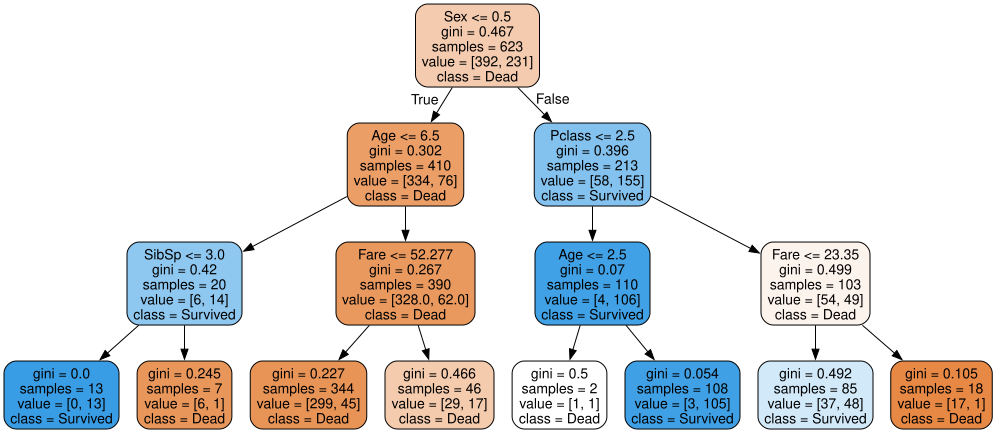

In [16]:
from sklearn.tree import export_graphviz
import graphviz

dot_data = export_graphviz(
    model,
    feature_names=X_train.columns,
    class_names=['Dead', 'Survived'],
    filled=True,
    rounded=True,
    proportion=False   # 건수 기준 출력
)
graphviz.Source(dot_data)

- 노드 비율 기준 출력

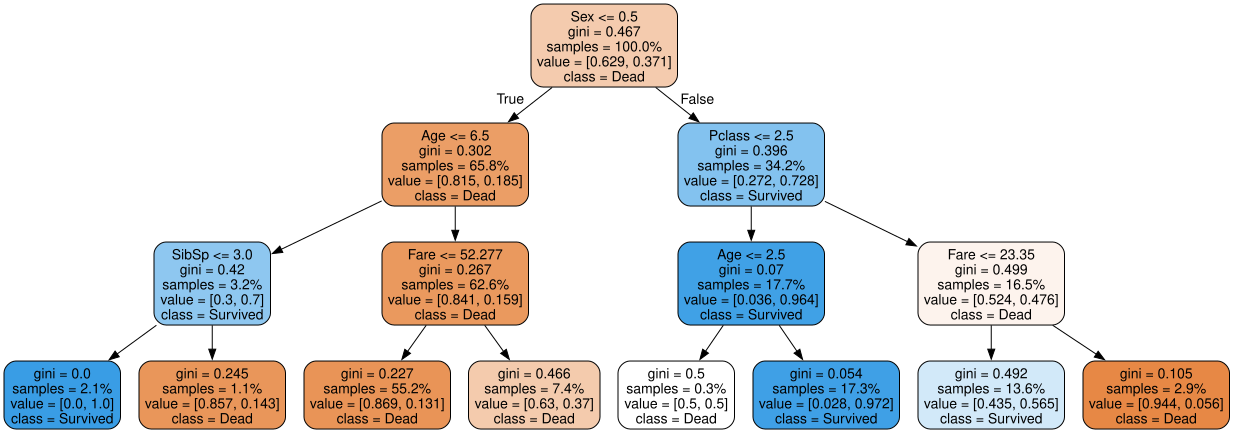

In [17]:
from sklearn.tree import export_graphviz
import graphviz

dot_data = export_graphviz(
    model,
    feature_names=X_train.columns,
    class_names=['Dead', 'Survived'],
    filled=True,
    rounded=True,
    proportion=True   # 비율 기준 출력
)
graphviz.Source(dot_data)

### [Self-Practice]

- 실습 주제 : Tree 시각화로 의사결정 경로 추적하기
- 실습 조건
   - DecisionTreeClassifier 에서 max_depth=4 로 설정
- 실습 시나리오
   - 시나리오 1) max_depth=3일 경우와 max_depth=4일 경우의 Test 정확도를 비교하세요.
   - 시나리오 2) 생존율이 가장 높은 집단과 가장 낮은 집단 (노드)의 규칙(Rule)을 각각 도출하세요.
   - 시나리오 3) Feature 중 성별, 연령, 형제자매수, 부모자녀수 는 현재 본인의 정보를 활용하고, Pclass(객실등급) 과 Fare(운임) 은 중위값 (median)으로 할 경우 생존율을 확인하세요.

In [18]:
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import accuracy_score

# 모델 정의
model_s = DecisionTreeClassifier(
    max_depth=4,       # Tree 깊이
    random_state=42
)

# 모델 학습
model_s.fit(X_train, y_train)

# 예측값 생성
train_pred = model_s.predict(X_train)
test_pred = model_s.predict(X_test)

# 모델 평가
print(f"Train 정확도: {accuracy_score(y_train, train_pred):.3f}")
print(f"Test  정확도: {accuracy_score(y_test, test_pred):.3f}")

Train 정확도: 0.848
Test  정확도: 0.821


### 시나리오 1 - max_depth=3일 경우와 max_depth=4일 경우의 Test 정확도를 비교하세요.

#### max_depth = 3일 경우
Test 정확도: 0.810

#### max_depth = 4일 경우
Test 정확도: 0.821

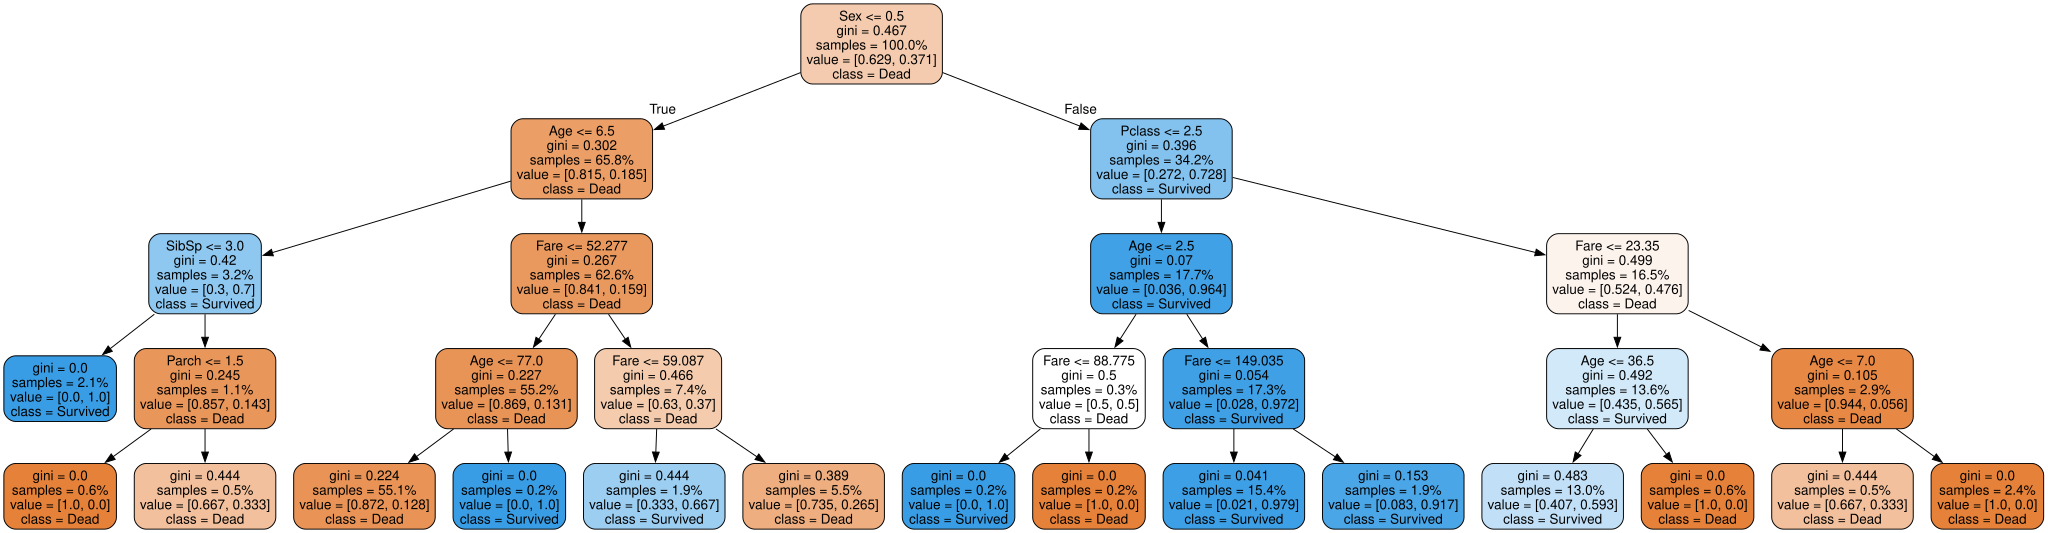

In [19]:
from sklearn.tree import export_graphviz
import graphviz

dot_data = export_graphviz(
    model_s,
    feature_names=X_train.columns,
    class_names=['Dead', 'Survived'],
    filled=True,
    rounded=True,
    proportion=True   # 비율 기준 출력
)
graphviz.Source(dot_data)

### 시나리오 2 - 생존율이 가장 높은 집단과 가장 낮은 집단 (노드)의 규칙(Rule)을 각각 도출하세요.


Feature Importance

  Feature  Importance
1     Sex    0.594041
0  Pclass    0.182446
5    Fare    0.088806
2     Age    0.086542
3   SibSp    0.048164
4   Parch    0.000000


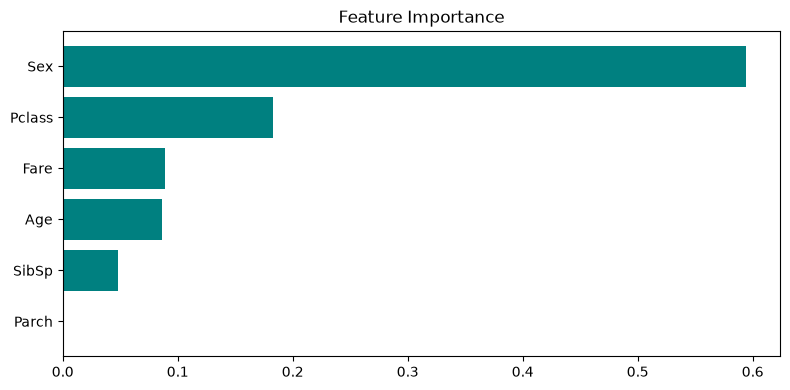

In [20]:
# Feature Importance
importance = pd.DataFrame({
    'Feature': X_train.columns,
    'Importance': model.feature_importances_
}).sort_values('Importance', ascending=False)

print(importance)

# 시각화
plt.figure(figsize=(8, 4))
plt.barh(importance["Feature"], importance["Importance"], color="teal")
plt.gca().invert_yaxis()
plt.title("Feature Importance")
plt.tight_layout()
plt.show()

# Random Forest
  - API 문서 : https://scikit-learn.org/stable/modules/generated/sklearn.ensemble.RandomForestClassifier.html

학습 및 예측

In [21]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score

# 모델 정의
model = RandomForestClassifier(
    n_estimators=100,       # 트리 개수
    max_depth=5,            # 각 트리의 최대 깊이
    random_state=42
)

# 모델 학습
model.fit(X_train, y_train)

# 예측값 생성
train_pred = model.predict(X_train)
test_pred = model.predict(X_test)

# 모델 평가
print(f"Train 정확도: {accuracy_score(y_train, train_pred):.3f}")
print(f"Test  정확도: {accuracy_score(y_test, test_pred):.3f}")

Train 정확도: 0.865
Test  정확도: 0.813


Feature Importance

  Feature  Importance
1     Sex    0.451847
5    Fare    0.191511
0  Pclass    0.132752
2     Age    0.129707
3   SibSp    0.051221
4   Parch    0.042962


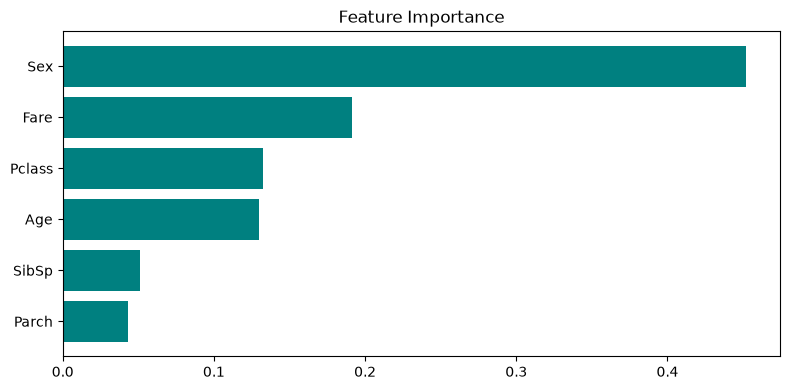

In [22]:
# Feature Importance
importance = pd.DataFrame({
    'Feature': X_train.columns,
    'Importance': model.feature_importances_
}).sort_values('Importance', ascending=False)

print(importance)

# 시각화
plt.figure(figsize=(8, 4))
plt.barh(importance["Feature"], importance["Importance"], color="teal")
plt.gca().invert_yaxis()
plt.title("Feature Importance")
plt.tight_layout()
plt.show()


In [23]:
%pip install lightgbm xgboost

Note: you may need to restart the kernel to use updated packages.


#  XGBoost
  - API 문서 : https://xgboost.readthedocs.io/en/stable/parameter.html

학습 및 예측

In [96]:
from xgboost import XGBClassifier
from sklearn.metrics import accuracy_score

# 모델 정의
model = XGBClassifier(
    n_estimators=10,    # 트리 개수
    max_depth=3,         # 각 트리의 최대 깊이
    learning_rate=0.20,   # 새로운 트리의 예측 결과를 얼마나 반영할지 결정, 최종 예측=이전까지의 예측+learning_rate×새 트리의 예측
    random_state=42,
)

# 모델 학습
model.fit(X_train, y_train)

# 예측값 생성
train_pred = model.predict(X_train)
test_pred = model.predict(X_test)

# 모델 평가
print(f"Train 정확도: {accuracy_score(y_train, train_pred):.3f}")
print(f"Test  정확도: {accuracy_score(y_test, test_pred):.3f}")

Train 정확도: 0.975
Test  정확도: 0.971


#  LightGBM
  - API 문서 : https://lightgbm.readthedocs.io/en/latest/pythonapi/lightgbm.LGBMClassifier.html

학습 및 예측

In [93]:
from lightgbm import LGBMClassifier
from sklearn.metrics import accuracy_score

# 모델 정의
model = LGBMClassifier(
    n_estimators=7,
    max_depth=2,
    learning_rate=0.3745,
    random_state=42,
    verbosity=-1      # 로그 출력 안 함
)

# 모델 학습
model.fit(X_train, y_train)

# 예측값 생성
train_pred = model.predict(X_train)
test_pred = model.predict(X_test)

# 모델 평가
print(f"Train 정확도: {accuracy_score(y_train, train_pred):.3f}")
print(f"Test  정확도: {accuracy_score(y_test, test_pred):.3f}")

Train 정확도: 0.977
Test  정확도: 0.988


### [Self-Practice 1]
Q) 모델별 하이퍼파라미터를 직접 변경하며 Test Accuracy를 비교하고, 가장 우수한 성능을 보이는 모델과 하이퍼파라미터 조합을 찾으세요. 단, 하이퍼파라미터 자동 최적화 기법은 사용하지 않음

### [Self-Practice 2]

- 실습 주제 : 유방암 음성/양성 진단 예측 모델 개발
- 실습 조건
  - 분석 데이타 : 아래 제시 코드의 데이타 활용
  - Target 변수 : target (0=악성, 1=양성)
  - 학습 조건 :
  데이터 분할 및 Feature Engineering(데이터 변환 포함) 과정은 아래 제시된 코드를 그대로 사용하고, 모델의 종류와 하이퍼파라미터 값만 자율적으로 선택
- 실습 시나리오
   - 시나리오 1) 모델별 하이퍼파라미터를 직접 변경하며 Test Accuracy를 비교하고, 가장 우수한 성능을 보이는 모델과 하이퍼파라미터 조합을 찾으세요. 단, 하이퍼파라미터 자동 최적화 기법은 사용하지 않음
   - 시나리오 2) Decision Tree 모델의 Tree 시각화에서 악성 비율이 가장 높은 집단과 양성 비율이 가장 높은 집단의 규칙(Rule)을 각각 도출하세요. 시각화의 가독성을 위해 max_depth를 적절히 제한
   - 시나리오 3) Random Forest 기준 특성 중요도(Feature Importance) 분석 결과 1~3위 Feature 는?
- [참고] 데이타 설명 : 유방암 세포 핵의 특성을 기반으로 악성·양성 여부를 분류하는 데이터셋

| 컬럼명 | 한글명 | 의미 | 비고 |
|--------|--------|------|------|
| mean radius | 평균 반지름 | 세포 핵의 평균 반지름 크기 | 연속형 |
| mean texture | 평균 질감 | 세포 핵 표면의 평균 질감 | 연속형 |
| mean perimeter | 평균 둘레 | 세포 핵의 평균 둘레 길이 | 연속형 |
| mean area | 평균 면적 | 세포 핵의 평균 면적 | 연속형 |
| mean smoothness | 평균 매끄러움 | 세포 핵 경계의 평균 매끄러운 정도 | 연속형 |
| mean compactness | 평균 조밀도 | 세포 핵이 얼마나 조밀하게 분포하는지 나타내는 정도 | 연속형 |
| mean concavity | 평균 오목함 | 세포 핵 경계의 평균 오목한 정도 | 연속형 |
| mean concave points | 평균 오목한 점 | 세포 핵 경계의 평균 오목한 점 개수 | 연속형 |
| worst radius | 최대 반지름 | 가장 큰(상위 3개 평균) 세포 핵의 반지름 | 연속형 |
| worst area | 최대 면적 | 가장 큰(상위 3개 평균) 세포 핵의 면적 | 연속형 |
| target | 유방암 진단 결과 | 0=악성(Malignant), 1=양성(Benign) | 종속변수 |

In [26]:
# ================================
# 데이타 불러오기
# ================================

from sklearn.datasets import load_breast_cancer
import pandas as pd

cancer = load_breast_cancer()

cols = [
    "mean radius",
    "mean texture",
    "mean perimeter",
    "mean area",
    "mean smoothness",
    "mean compactness",
    "mean concavity",
    "mean concave points",
    "worst radius",
    "worst area"
]

df = pd.DataFrame(cancer.data, columns=cancer.feature_names)
df = df[cols]
df["target"] = cancer.target
print(df.head())


# ================================
# 데이타 분할
# ================================

from sklearn.model_selection import train_test_split

# X, y 분리
X = df.drop('target', axis=1)
y = df['target']

# Train/Test 분리
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.3, random_state=42
)

   mean radius  mean texture  mean perimeter  mean area  mean smoothness  \
0        17.99         10.38          122.80     1001.0          0.11840   
1        20.57         17.77          132.90     1326.0          0.08474   
2        19.69         21.25          130.00     1203.0          0.10960   
3        11.42         20.38           77.58      386.1          0.14250   
4        20.29         14.34          135.10     1297.0          0.10030   

   mean compactness  mean concavity  mean concave points  worst radius  \
0           0.27760          0.3001              0.14710         25.38   
1           0.07864          0.0869              0.07017         24.99   
2           0.15990          0.1974              0.12790         23.57   
3           0.28390          0.2414              0.10520         14.91   
4           0.13280          0.1980              0.10430         22.54   

   worst area  target  
0      2019.0       0  
1      1956.0       0  
2      1709.0       0  
3 

In [99]:
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import accuracy_score

# 모델 정의
model = DecisionTreeClassifier(
    max_depth=2,       # Tree 깊이
    random_state=42
)

# 모델 학습
model.fit(X_train, y_train)

# 예측값 생성
train_pred = model.predict(X_train)
test_pred = model.predict(X_test)

# 모델 평가
print(f"Train 정확도: {accuracy_score(y_train, train_pred):.3f}")
print(f"Test  정확도: {accuracy_score(y_test, test_pred):.3f}")

Train 정확도: 0.927
Test  정확도: 0.918


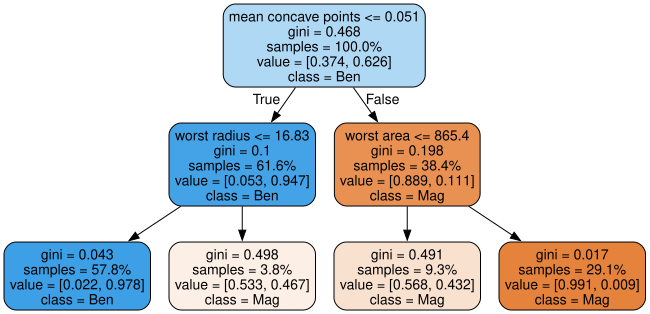

In [104]:
from sklearn.tree import export_graphviz
import graphviz

dot_data = export_graphviz(
    model,
    feature_names=X_train.columns,
    class_names=['Mag', 'Ben'],
    filled=True,
    rounded=True,
    proportion=True   # 비율 기준 출력
)
graphviz.Source(dot_data)

시나리오 2) Decision Tree 모델의 Tree 시각화에서 악성 비율이 가장 높은 집단과 양성 비율이 가장 높은 집단의 규칙(Rule)을 각각 도출하세요. 시각화의 가독성을 위해 max_depth를 적절히 제한

악성
- 평균 오목한 점의 개수 비율이 0.051보다 크고, 가장 큰 핵 3개의 평균 면적이 865.4보다 크면 악성이다.

양성
- 평균 오목한 점의 개수 비율이 0.051보다 작거나 같고, 가장 큰 핵 3개의 평균 면적이 16.83보다 작거나 같으면 양성이다.

In [133]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score

# 모델 정의
model = RandomForestClassifier(
    n_estimators=100,       # 트리 개수
    max_depth=5,            # 각 트리의 최대 깊이
    random_state=42
)

# 모델 학습
model.fit(X_train, y_train)

# 예측값 생성
train_pred = model.predict(X_train)
test_pred = model.predict(X_test)

# 모델 평가
print(f"Train 정확도: {accuracy_score(y_train, train_pred):.3f}")
print(f"Test  정확도: {accuracy_score(y_test, test_pred):.3f}")

Train 정확도: 0.992
Test  정확도: 0.965


               Feature  Importance
7  mean concave points    0.279960
9           worst area    0.189533
8         worst radius    0.150743
6       mean concavity    0.149026
2       mean perimeter    0.072799
1         mean texture    0.042464
3            mean area    0.039615
0          mean radius    0.033581
5     mean compactness    0.023646
4      mean smoothness    0.018634


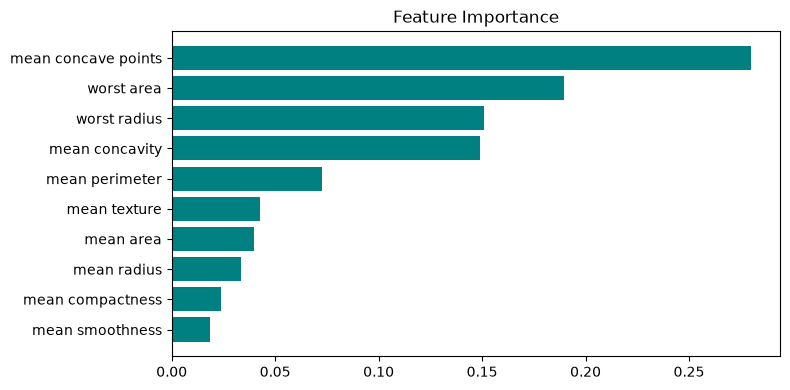

In [134]:
# Feature Importance
importance = pd.DataFrame({
    'Feature': X_train.columns,
    'Importance': model.feature_importances_
}).sort_values('Importance', ascending=False)

print(importance)

# 시각화
plt.figure(figsize=(8, 4))
plt.barh(importance["Feature"], importance["Importance"], color="teal")
plt.gca().invert_yaxis()
plt.title("Feature Importance")
plt.tight_layout()
plt.show()


시나리오 3) Random Forest 기준 특성 중요도(Feature Importance) 분석 결과 1~3위 Feature 는?

1. 평균 오목한 점
2. 최대 면적
3. 최대 반지름

In [132]:
from xgboost import XGBClassifier
from sklearn.metrics import accuracy_score

# 모델 정의
model = XGBClassifier(
    n_estimators=8,    # 트리 개수
    max_depth=8,         # 각 트리의 최대 깊이
    learning_rate=0.28,   # 새로운 트리의 예측 결과를 얼마나 반영할지 결정, 최종 예측=이전까지의 예측+learning_rate×새 트리의 예측
    random_state=42,
)

# 모델 학습
model.fit(X_train, y_train)

# 예측값 생성
train_pred = model.predict(X_train)
test_pred = model.predict(X_test)

# 모델 평가
print(f"Train 정확도: {accuracy_score(y_train, train_pred):.3f}")
print(f"Test  정확도: {accuracy_score(y_test, test_pred):.3f}")

Train 정확도: 0.992
Test  정확도: 0.977
